In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import geoflowkit as gfk

In [3]:
fdf = gfk.read_csv('./data/sz_data/sz_taxi_flow.csv', use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
fdf.shape, type(fdf)

((10000, 10), geoflowkit.flowdataframe.FlowDataFrame)

In [4]:
df = pd.read_csv('./data/sz_data/sz_taxi_flow.csv')
fdf = gfk.FlowDataFrame(df, geometry=gfk.flows_from_od(df[['ox', 'oy']], df[['dx', 'dy']]), crs='EPSG:4326')
fdf.head()

,UID,stime,ox,oy,etime,dx,dy,distance,time_difference,geometry
0,32324,17:26:04,114.024651,22.527000,17:51:16,114.041283,22.553984,3.452617,1512,"MULTIPOINT (114.02 22.527, 114.04 22.554)"
1,28591,15:30:09,114.101952,22.552500,16:28:07,113.809319,22.627451,31.177366,3478,"MULTIPOINT (114.1 22.552, 113.81 22.627)"
2,28805,20:59:16,114.067680,22.523867,21:13:07,114.028687,22.526382,4.014803,831,"MULTIPOINT (114.07 22.524, 114.03 22.526)"
3,22909,17:04:55,114.236618,22.713150,17:13:38,114.250298,22.721783,1.700085,523,"MULTIPOINT (114.24 22.713, 114.25 22.722)"
4,35077,14:35:04,114.099564,22.549250,14:59:59,114.079002,22.545467,2.153116,1495,"MULTIPOINT (114.1 22.549, 114.08 22.545)"


In [5]:
fdf.to_crs(4526, inplace=True)
type(fdf)

geoflowkit.flowdataframe.FlowDataFrame

In [6]:
type(fdf.iloc[:100])

geoflowkit.flowdataframe.FlowDataFrame

In [7]:
fdf = fdf.to_crs(4526)
type(fdf)

geoflowkit.flowdataframe.FlowDataFrame

In [8]:
fdf.density, fdf.volume

(3.508335763442165e-06, 2850354320.18873)

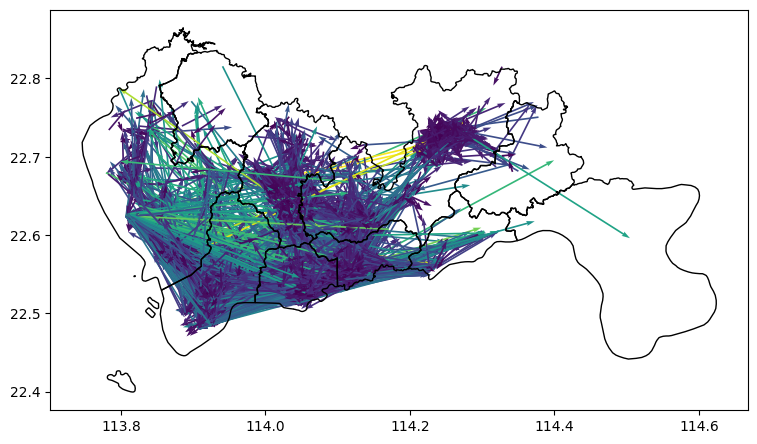

In [9]:
fdf.to_crs(4326, inplace=True)
gdf = gpd.read_file('./data/sz_data/sz_border.gpkg')
ax = fdf.plot(figsize=(9, 6), column='distance')
gdf.plot(ax=ax, facecolor="none", edgecolor="black");

In [10]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset2.gpkg')
fdf.head(1)

,index,ox,oy,dx,dy,angle,length,flow_type,type_num,geometry
0,0,0.933863,0.056809,0.977145,0.494712,1.4725,1.099471,scatter2,7,"MULTIPOINT (0.93386 0.056809, 0.97714 0.49471)"


In [11]:
type(fdf)

geoflowkit.flowdataframe.FlowDataFrame

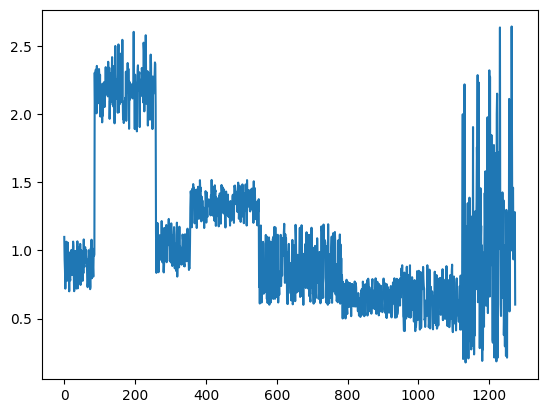

In [12]:
fdf['length'].plot(kind='line');

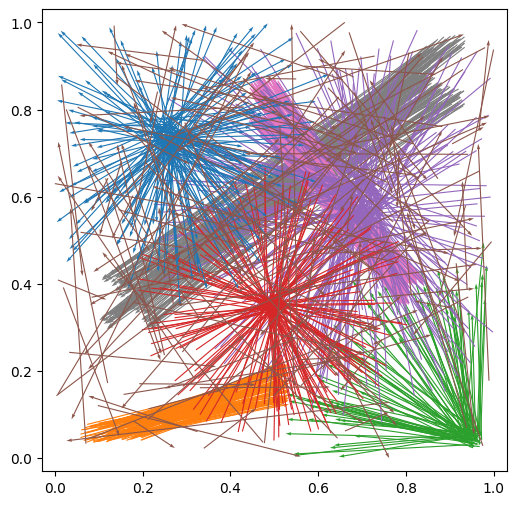

In [13]:
from matplotlib.colors import ListedColormap
labels = fdf['flow_type']
unique_labels = list(set(labels))
num_unique_labels = len(unique_labels)
cmap = ListedColormap(plt.cm.tab10.colors[:num_unique_labels]) 
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}
colors = [label_to_color[label] for label in labels]

fdf.plot(color=colors, figsize=(6, 6));